In [28]:
import numpy as np


num_frequencies = 16
length_scale  = 1. # in Angstroms.

grid_fourier_x =   np.arange(num_frequencies) / (num_frequencies-1) * 2 * np.pi/ length_scale
grid_fourier_y =   np.arange(num_frequencies) / (num_frequencies-1) * 2 * np.pi / length_scale
grid_fourier_z =   np.arange(num_frequencies) / (num_frequencies-1) * 2 * np.pi / length_scale
grid_fourier_triplets = np.stack(np.meshgrid(grid_fourier_x,grid_fourier_y,grid_fourier_z,indexing='ij'),axis=-1).reshape([-1,3])


def fourier_encoding(x):
    arguments_to_cosines = np.dot(x, grid_fourier_triplets.T)
    return np.concatenate([np.cos(arguments_to_cosines), np.sin(arguments_to_cosines)],axis=-1)
    
    




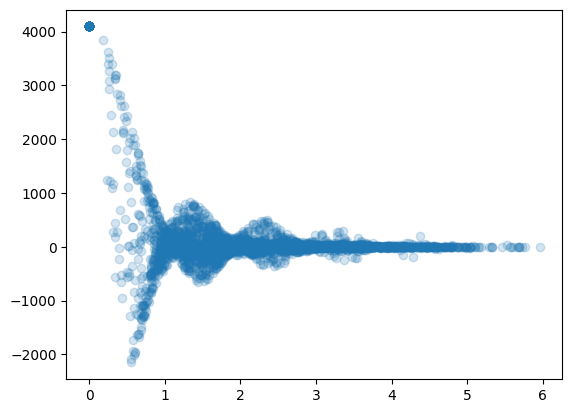

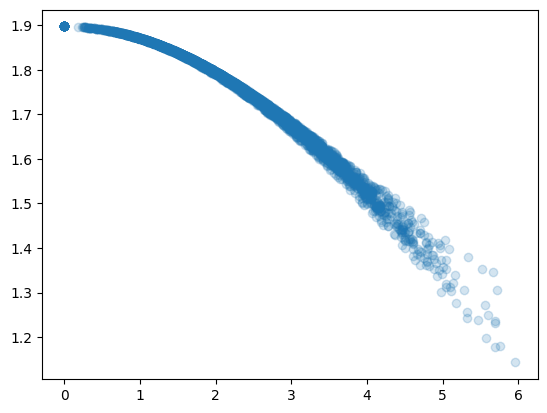

In [ ]:
import matplotlib.pyplot as plt

N = 100
x = np.random.randn(N,3)

pairwise_distances = np.sqrt( ((x[np.newaxis] - x[:,np.newaxis])**2).sum(-1) )

encodings = fourier_encoding(x) # stop_gradient...


norm_grids = (grid_fourier_triplets**2).sum(-1)

inverse_fourier = np.exp( - 20* norm_grids**2)
inverse_fourier = np.concatenate((inverse_fourier,inverse_fourier),axis=-1)

pairwise_angles = np.dot(encodings,encodings.T)

encodings2 = encodings * inverse_fourier[np.newaxis]
pairwise_angles2 = np.dot(encodings2,encodings2.T)


plt.scatter(pairwise_distances,pairwise_angles,alpha=0.1); plt.show()
plt.scatter(pairwise_distances,pairwise_angles2,alpha=0.1); plt.show()